
# Линейная регрессия

# Прогнозирование цен на жильё
## О задаче

Датасет `sales.csv` содержит информацию о продажах квартир (1460 записей).
Целевая переменная — **SalePrice** (цена продажи).
Признаки: GrLivArea (жилая площадь), GarageArea (площадь гаража),
OverallQual (общее качество), Street (тип улицы), SaleCondition (условия сделки).

**Цель работы:** построить модель линейной регрессии, прогнозирующую цену,
и честно оценить её качество на отложенной тестовой выборке.

## Ключевая проблема данных

Распределение `SalePrice` сильно скошено вправо. Такой длинный хвост типичен для
цен на недвижимость и создаёт несколько проблем:

1. Линейная регрессия с MSE чувствительна к крупным значениям —
   модель «тянется» к дорогим объектам в ущерб дешёвым.
2. На дорогих объектах модель систематически недооценивает цену.
3. Остатки имеют гетероскедастичность (веерообразный разброс).

## Что делается в работе

1. Первичный анализ: описательные статистики, корреляционная матрица, pairplot.
2. Кодирование категориальных признаков через one-hot.
3. Логарифмирование таргета (`log1p`) для симметризации распределения.
4. Удаление двух выбросов **только из train** (тест оставлен полным).
5. Сравнение трёх моделей: LR, log-LR, log-LR без выбросов.
6. Оценка через MAE и MSE, анализ остатков, проверка на гетероскедастичность.

### 1. Импорт библиотек

In [182]:
# Ваш код здесь
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

### 2. Загрузка данных

In [183]:
# Ваш код здесь
df = pd.read_csv('/content/sales.csv')

### 3. Первичный анализ

1. Aнализ данных, индивидуальные графики зависимости целевой функции и отдельной переменной.
2. Кодировка категориальных признаков ( с помощью [pd.get_dummies])
3. Предварительные выводы.

In [184]:
# Ваш код здесь
print(df.head(2))

   SalePrice  GrLivArea  GarageArea  OverallQual Street SaleCondition
0     208500       1710         548            7   Pave        Normal
1     181500       1262         460            6   Pave        Normal


In [185]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   SalePrice      1460 non-null   int64 
 1   GrLivArea      1460 non-null   int64 
 2   GarageArea     1460 non-null   int64 
 3   OverallQual    1460 non-null   int64 
 4   Street         1460 non-null   object
 5   SaleCondition  1460 non-null   object
dtypes: int64(4), object(2)
memory usage: 68.6+ KB
None


In [186]:
print(df.isnull().sum())

SalePrice        0
GrLivArea        0
GarageArea       0
OverallQual      0
Street           0
SaleCondition    0
dtype: int64


In [187]:
print(df.describe())

           SalePrice    GrLivArea   GarageArea  OverallQual
count    1460.000000  1460.000000  1460.000000  1460.000000
mean   180921.195890  1515.463699   472.980137     6.099315
std     79442.502883   525.480383   213.804841     1.382997
min     34900.000000   334.000000     0.000000     1.000000
25%    129975.000000  1129.500000   334.500000     5.000000
50%    163000.000000  1464.000000   480.000000     6.000000
75%    214000.000000  1776.750000   576.000000     7.000000
max    755000.000000  5642.000000  1418.000000    10.000000


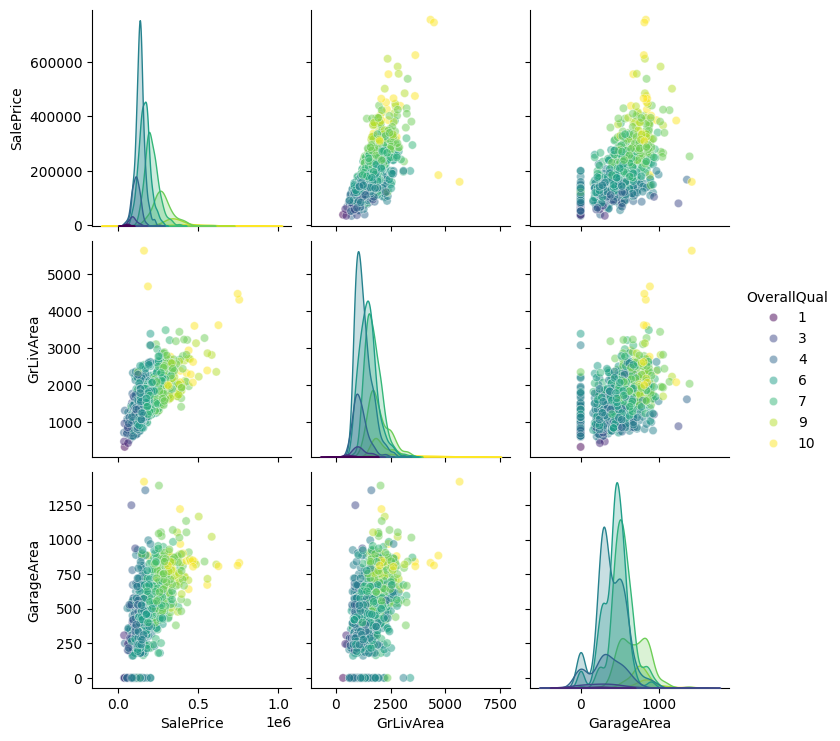

In [188]:
sns.pairplot(df, hue='OverallQual',
             palette='viridis', plot_kws={'alpha': 0.5})
plt.show()
# Pairplot: визуально оцениваем связь каждого кат.признака с SalePrice и распределения.

In [189]:
outline = df[(df.GrLivArea > 4000) & (df.SalePrice < 300000)] # посмотрим на аномальные значения(огроманя площадь, низкая цена)
print(outline)

      SalePrice  GrLivArea  GarageArea  OverallQual Street SaleCondition
523      184750       4676         884           10   Pave       Partial
1298     160000       5642        1418           10   Pave       Partial


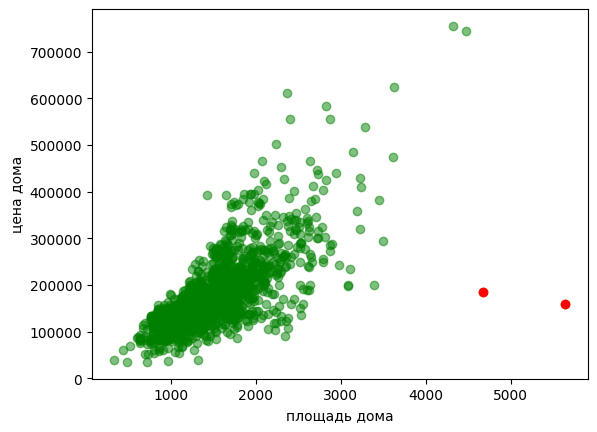

In [190]:
plt.scatter(df.GrLivArea, df.SalePrice, alpha = 0.5, c='g')
plt.scatter(outline.GrLivArea, outline.SalePrice, c='r')
plt.xlabel('площадь дома')
plt.ylabel('цена дома')
plt.show()

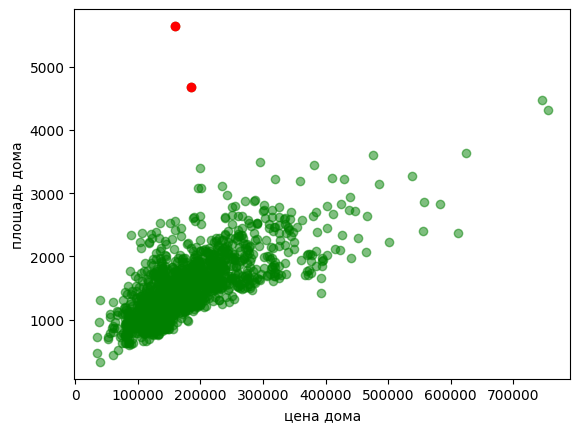

In [191]:
plt.scatter(df.SalePrice, df.GrLivArea, alpha=0.5, c='g')
plt.scatter(outline.SalePrice, outline.GrLivArea, c='r')
plt.xlabel('цена дома')
plt.ylabel('площадь дома')
plt.show()

Красным цветом на графиках выделены выбросы, эти дома имеют очень низкую цену при огомной площади и общем качестве 10. Для лучшего обучения модели мы исключим их из обучающей выборки.

In [192]:
df_encoded = pd.get_dummies(df, dtype=int, drop_first=True)

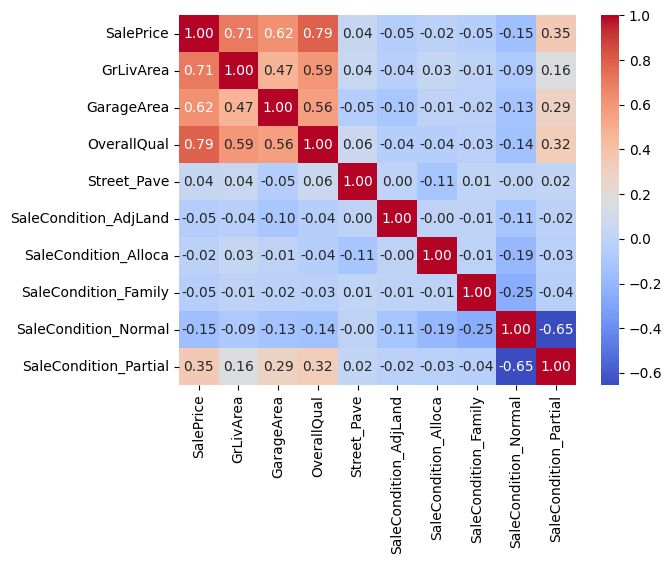

In [193]:
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

Корреляционная матрица показывает, что SalePrice сильнее всего коррелирует с OverallQual (0.79) и GrLivArea (0.71). Категориальные признаки после one-hot имеют слабую корреляцию, что ожидаемо для бинарных переменных.

### 4. Разделение на обучающую и тестовую выборки

In [194]:
# Ваш код здесь
x = df_encoded.drop(columns='SalePrice')
y = df_encoded[['SalePrice']]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=21)

логарифмируем целевую переменную для борьбы со скошенностью данных

In [195]:
log_y_train = np.log1p(y_train) #  log1p (log(1+x)) — это безопасно при x >= 0.
log_y_test = np.log1p(y_test)

избавляемся от выбросов на обучающей выборке

In [196]:
mask = (x_train.GrLivArea > 4000) & (y_train.SalePrice < 300000)
x_train_mask = x_train[~mask]
y_train_mask = y_train[~mask]
log_y_train_mask = log_y_train[~mask]

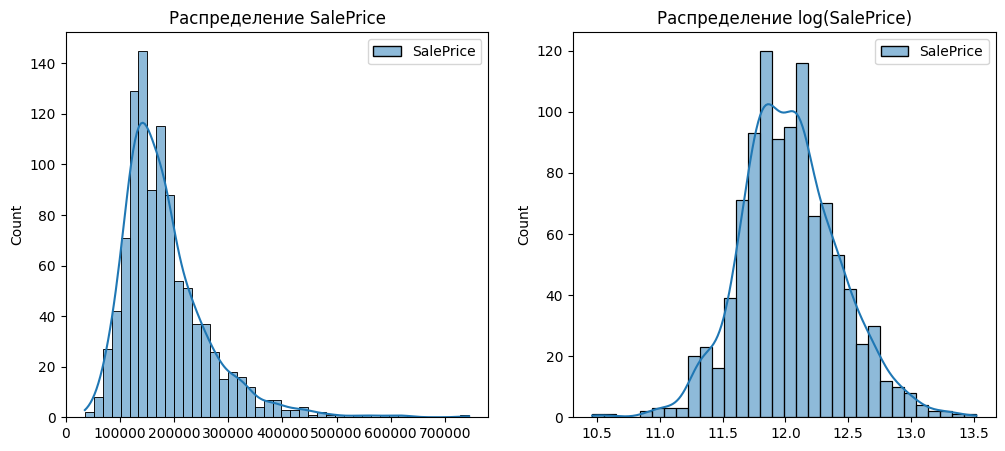

In [197]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(y_train_mask, kde=True)
plt.title('Распределение SalePrice')
plt.subplot(1, 2, 2)
sns.histplot(log_y_train_mask, kde=True)
plt.title('Распределение log(SalePrice)')
plt.show()

Видно, что логарифмирование сделало распределение более симметричным (близким к нормальному), что является предпочтительным для линейной регрессии.

### 5. Обучение модели линейной регрессии

Дополнительно можно взглянуть на коэффициенты и смещение обученной модели.

In [198]:
# Ваш код здесь
linear_regression = LinearRegression()
linear_regression.fit(x_train, y_train)

LinearRegression()

In [199]:
print(f'w0  for y train: {linear_regression.intercept_}')
print(f'w for y train: {linear_regression.coef_}')

w0  for y train: [-113861.18267153]
w for y train: [[   60.41594826    64.12360517 25271.96462825  9168.02293285
   8079.65623905  7791.31202946 -3993.54454306  7620.85708058
  38267.41365869]]


обучение модели на логарифмированной целевой переменной

In [200]:
log_lr = LinearRegression()
log_lr.fit(x_train, log_y_train)

LinearRegression()

In [201]:
print(f'w0 for log_y train :{log_lr.intercept_}')
print(f'w for log_y train :{log_lr.coef_}')

w0 for log_y train :[10.33699625]
w for log_y train :[[ 0.00026376  0.00038055  0.13616229  0.18067468 -0.0350334   0.04764547
   0.02651375  0.10062562  0.18901897]]


обучение модели без выбросов на логарифмированной целевой перемой

In [202]:
llr = LinearRegression()
llr.fit(x_train_mask, log_y_train_mask)

LinearRegression()

In [203]:
w = llr.coef_
f_names = x_train.columns
w_columns = pd.DataFrame(
    {'Column name': f_names,
     'w0 coef_' : w.flatten()}).sort_values(by='w0 coef_', ascending=False)
print(w_columns)

             Column name  w0 coef_
8  SaleCondition_Partial  0.189019
3            Street_Pave  0.180675
2            OverallQual  0.136162
7   SaleCondition_Normal  0.100626
5   SaleCondition_Alloca  0.047645
6   SaleCondition_Family  0.026514
1             GarageArea  0.000381
0              GrLivArea  0.000264
4  SaleCondition_AdjLand -0.035033


В данном случае признаки имеют различный маштаб, поэтому оценка важности признаков по коэффициентам регрессии не производится.

### 6. Получение предсказаний для обучающей и тестовой выборок

In [204]:
# Ваш код здесь
predict_train_regression = linear_regression.predict(x_train)
predict_test_regression = linear_regression.predict(x_test)

на логарифмированной целевой переменной

In [205]:
log_predict_train_regression = log_lr.predict(x_train)
log_predict_test_regression = log_lr.predict(x_test)

predict_train_regression2 = np.expm1(log_predict_train_regression)
predict_test_regression2 = np.expm1(log_predict_test_regression)

на логарифмированной целевой переменной, с исключенными выбросами

In [206]:
llr_train = llr.predict(x_train_mask)
llr_test = llr.predict(x_test)

predict_train_llr = np.expm1(llr_train)
predict_test_llr = np.expm1(llr_test)

### 7. Проверка предсказаний

1. Проверьте качество модели на обучающей и тестовой выборках с помощью MAE, MSE.
2. Постройте диаграмму рассеяния целевой и предсказанной переменных.

In [207]:
# Ваш код здесь
mae_train = mean_absolute_error(y_train, predict_train_regression)
mae_test = mean_absolute_error(y_test, predict_test_regression)
print(f'mae for train: {mae_train}')
print(f'mae for test: {mae_test}')

mae for train: 26569.250553117025
mae for test: 27616.60210632684


In [208]:
mse_train = mean_squared_error(y_train, predict_train_regression)
mse_test = mean_squared_error(y_test, predict_test_regression)
print(f'mse for train: {mse_train}')
print(f'mse for test: {mse_test}')

mse for train: 1411400689.0609531
mse for test: 2046083309.065859


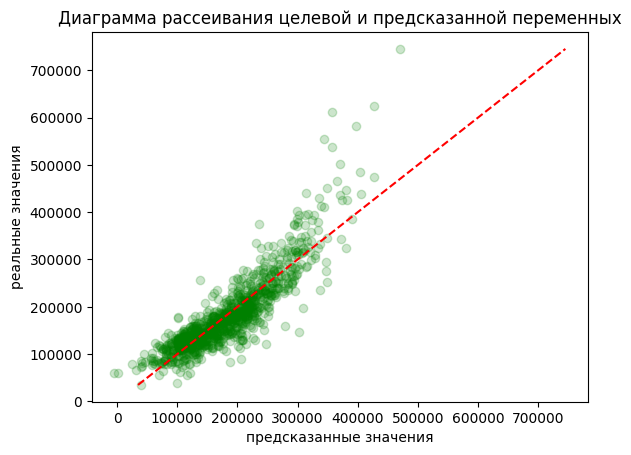

In [209]:
plt.scatter(predict_train_regression, y_train, c='g', alpha=0.2)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()], 'r--')
plt.xlabel('предсказанные значения')
plt.ylabel('реальные значения')
plt.title('Диаграмма рассеивания целевой и предсказанной переменных')
plt.show()

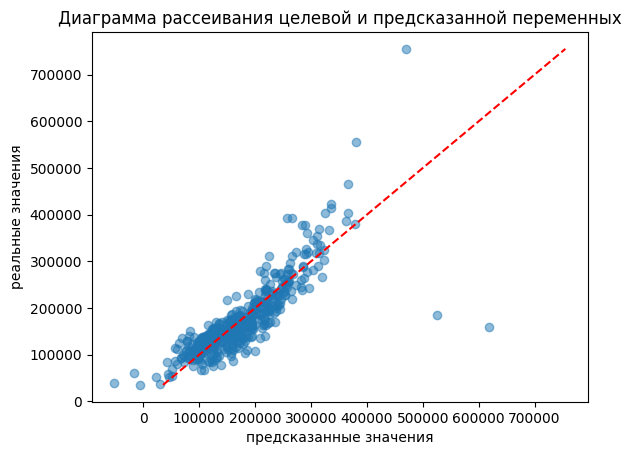

In [210]:
plt.scatter(predict_test_regression, y_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('предсказанные значения')
plt.ylabel('реальные значения')
plt.title('Диаграмма рассеивания целевой и предсказанной переменных')
plt.show()

качество модели для логарифмированной целевой переменной

In [211]:
mae_train = mean_absolute_error(y_train, predict_train_regression2)
mae_test = mean_absolute_error(y_test, predict_test_regression2)
print(f'mae for train: {mae_train}')
print(f'mae for test: {mae_test}')

mae for train: 22971.036322084292
mae for test: 25869.74804044487


In [212]:
mse_train = mean_squared_error(y_train, predict_train_regression2)
mse_test = mean_squared_error(y_test, predict_test_regression2)
print(f'mse for train: {mse_train}')
print(f'mse for test: {mse_test}')

mse for train: 1079409992.8949502
mse for test: 4937506990.758676


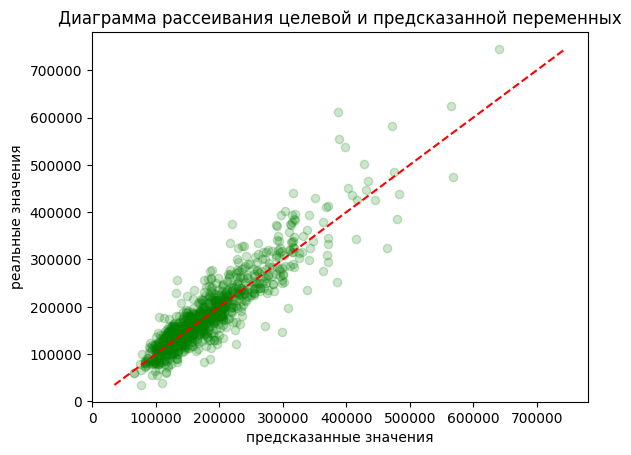

In [213]:
plt.scatter(predict_train_regression2, y_train, c='g', alpha=0.2)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()], 'r--')
plt.xlabel('предсказанные значения')
plt.ylabel('реальные значения')
plt.title('Диаграмма рассеивания целевой и предсказанной переменных')
plt.show()

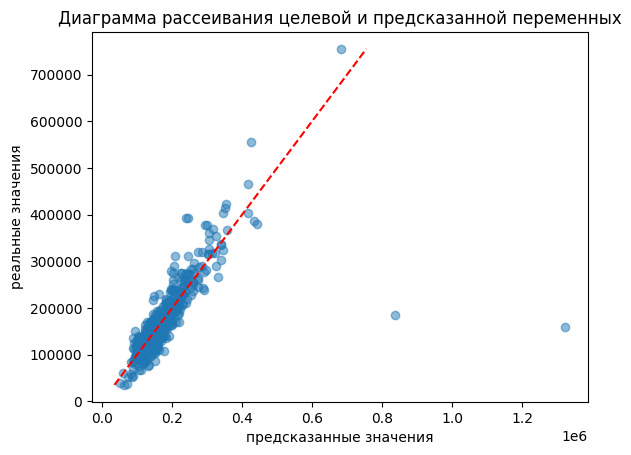

In [214]:
plt.scatter(predict_test_regression2, y_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('предсказанные значения')
plt.ylabel('реальные значения')
plt.title('Диаграмма рассеивания целевой и предсказанной переменных')
plt.show()

качество модели для логарифмированной целевой переменной с удаленными выбросами

In [215]:
mae_train_lrr = mean_absolute_error(y_train_mask, predict_train_llr)
mae_test_lrr = mean_absolute_error(y_test, predict_test_llr)

print(f'mae:', mae_train_lrr)
print(f'mae:', mae_test_lrr)

mae: 22971.036322084292
mae: 25869.74804044487


In [216]:
mse_train_lrr = mean_squared_error(y_train_mask, predict_train_llr)
mse_test_lrr = mean_squared_error(y_test, predict_test_llr)

print(f'mae:',mse_train_lrr)
print(f'mae:',mse_test_lrr)

mae: 1079409992.8949502
mae: 4937506990.758676


Логарифмирование таргета и удаление выбросов из train улучшили MAE на тесте (27.6 → 25.9 тыс.), что говорит о лучшем качестве модели на типичных объектах. Однако MSE на тесте вырос, потому что в тесте остались аномальные объекты (частичные продажи с большой площадью и низкой ценой), на которых лог-модель ошибается сильнее. Это ожидаемое поведение: тест отражает реальное распределение, включая выбросы, и мы не должны их удалять, чтобы оценка была честной

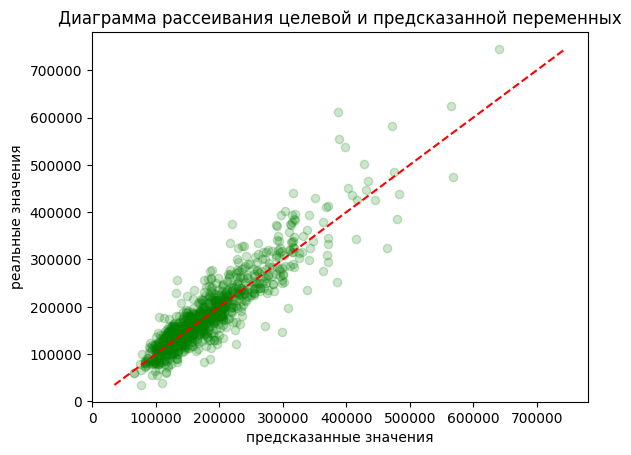

In [217]:
plt.scatter(predict_train_llr, y_train_mask, c='g', alpha=0.2)
plt.plot([y_train_mask.min(), y_train_mask.max()],
         [y_train_mask.min(), y_train_mask.max()], 'r--')
plt.xlabel('предсказанные значения')
plt.ylabel('реальные значения')
plt.title('Диаграмма рассеивания целевой и предсказанной переменных')
plt.show()

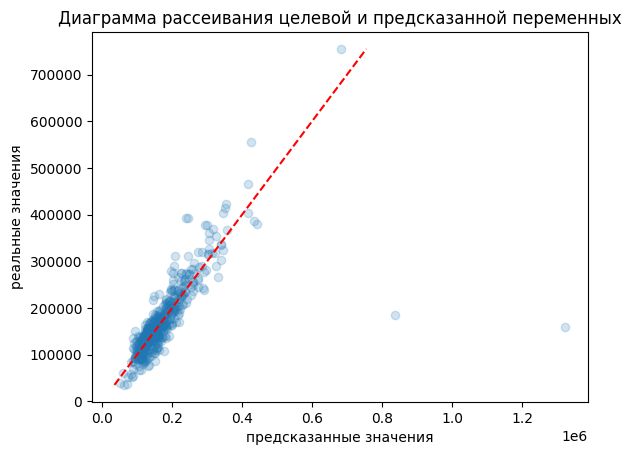

In [218]:
plt.scatter(predict_test_llr, y_test, alpha=0.2)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('предсказанные значения')
plt.ylabel('реальные значения')
plt.title('Диаграмма рассеивания целевой и предсказанной переменных')
plt.show()

## 8. Оценка результатов линейной регрессии

построим графики остатков

модель 1

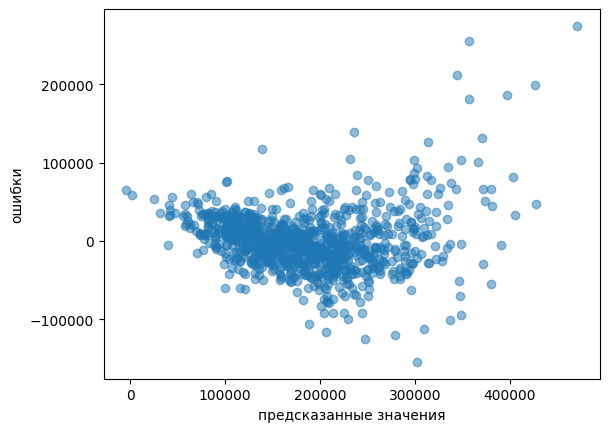

In [219]:
err_1 = y_train - predict_train_regression
plt.scatter(predict_train_regression, err_1, alpha=0.5)
plt.xlabel('предсказанные значения')
plt.ylabel('ошибки')
plt.show()

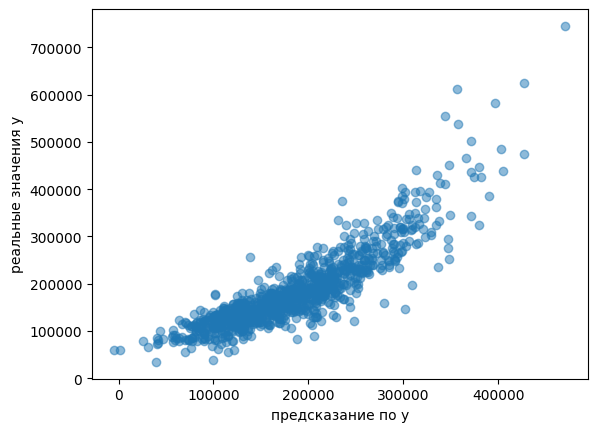

In [220]:
plt.scatter(predict_train_regression, y_train, alpha=0.5)
plt.xlabel('предсказание по y')
plt.ylabel('реальные значения y')
plt.show()

# Веерообразный разброс (гетероскедастичность) означает,
# что дисперсия ошибок растёт с ростом предсказания.
# Это нарушает одно из допущений линейной регрессии и
# делает MSE менее надёжной метрикой.

модель 2

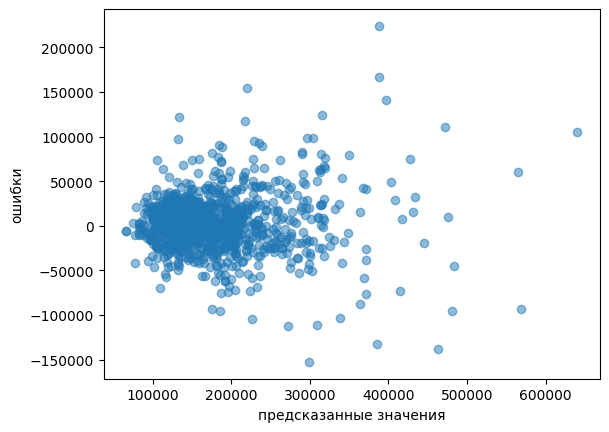

In [221]:
err_2 = y_train - predict_train_regression2
plt.scatter(predict_train_regression2, err_2, alpha=0.5)
plt.xlabel('предсказанные значения')
plt.ylabel('ошибки')
plt.show()

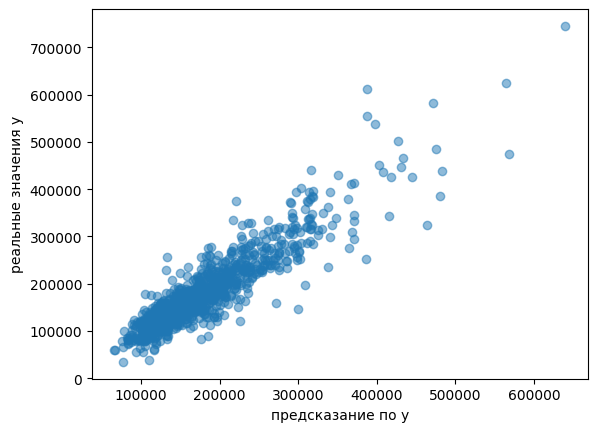

In [222]:
plt.scatter(predict_train_regression2, y_train, alpha=0.5)
plt.xlabel('предсказание по y')
plt.ylabel('реальные значения y')
plt.show()
# После логарифмирования веер становится менее выраженным, но не исчезает полностью.

модель 3

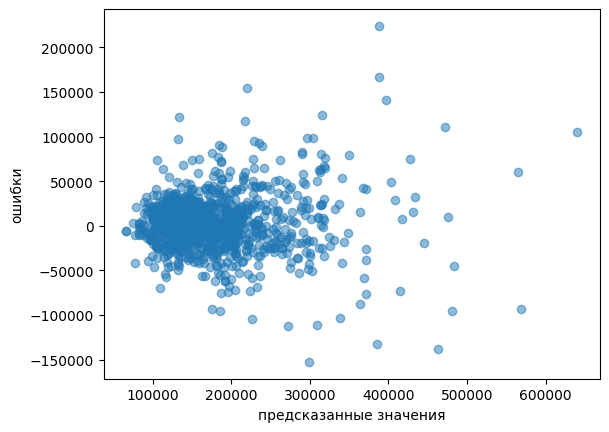

In [223]:
err = y_train_mask - predict_train_llr
plt.scatter(predict_train_llr, err, alpha=0.5)
plt.xlabel('предсказанные значения')
plt.ylabel('ошибки')
plt.show()

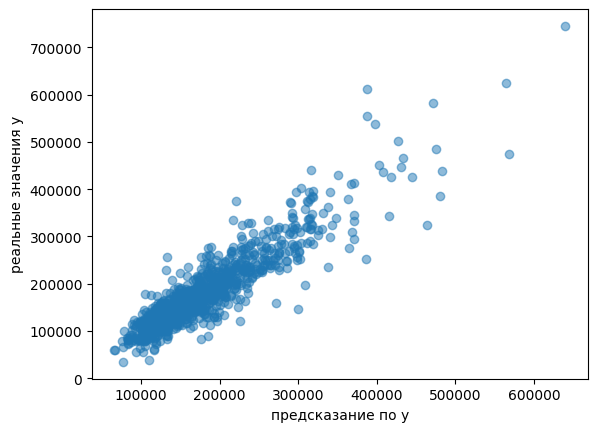

In [224]:
plt.scatter(predict_train_llr, y_train_mask, alpha=0.5)
plt.xlabel('предсказание по y')
plt.ylabel('реальные значения y')
plt.show()

## Вывод



1. **Логарифмирование таргета дало основной выигрыш**:
   MAE на тесте снизился с 27 617 до 25 870 (≈6.3%).

2. **Удаление двух выбросов из train не изменило метрики**:
   их доля (0.2%) слишком мала, чтобы повлиять на коэффициенты.
   Процедура важна методологически — она защищает модель
   в датасетах с большим числом аномалий.

3. **MSE на тесте у лог.модели выше**, чем у обычной.
   Это не деградация модели, а следствие того, что:
   - тест оставлен полным (с выбросами) для честной оценки;
   - MSE чувствителен к крупным абсолютным ошибкам;
   - 2 аномальных объекта из 438 дают ~90% вклада в MSE.

Логарифмирование ослабило гетероскедастичность остатков: веер стал менее выраженным, а разброс ошибок — более равномерным по диапазону предсказаний. Полностью гетероскедастичность не исчезла, поскольку после обратного преобразования (expm1) относительная ошибка снова превращается в абсолютную, которая растёт с ценой. В лог-пространстве остатки распределены существенно однороднее